# Sleep-EDF 睡眠分期：SNN 与动力学分析

本 Notebook 是一个从原始脑电数据到模型评估的完整小实验。**EEG（脑电图）**是在头皮上测量到的电压变化；这里使用公开的 Sleep-EDF 睡眠数据，尝试根据脑电特征识别睡眠阶段。

首次运行会通过 MNE 下载数据；当前默认只使用 2 位受试者，让流程较快跑通。先把它当作学习用的实验，不代表完整数据集上的最终结论。

建议从上到下执行。代码单元负责计算，Markdown 文字单元负责解释；如果修改代码后结果看起来不对，可以从菜单重启 Notebook 内核，再从顶部重新运行。

## 1. 环境与可复现设置

这一格导入后续会用到的工具：NumPy 管理数组，PyTorch 训练神经网络，scikit-learn 提供数据划分和基线模型，Matplotlib 负责画图。`sys.path` 让 Notebook 能找到仓库 `src/` 下的 `snn_eeg` 模块。

`SEED = 42` 固定随机数种子，让随机划分、脉冲采样和模型初始化在同一环境下尽量可复现。`DEVICE` 会优先选择可用的 CUDA GPU；没有 CUDA 时使用 CPU。Mac 上没有 CUDA 是正常的。

In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from snn_eeg.data import load_sleep_edf
from snn_eeg.encoding import rate_encode
from snn_eeg.models import TwoLayerSNN
from snn_eeg.baselines import make_baselines
from snn_eeg.metrics import classification_metrics, spike_activity

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

## 2. 获取并预处理数据：MNE 滤波、epoch 与频带功率

`load_sleep_edf` 通过 MNE 获取 PSG（脑电等生理信号）文件和 hypnogram（睡眠阶段标注），只保留 EEG 通道，进行 0.3–35 Hz 带通滤波，再按标注切成约 30 秒的片段（epoch）。`data.py` 会剔除幅度明显异常的片段，并把每段 EEG 转成 5 个频带的功率特征。

**频带功率**可以粗略理解为信号在一段频率范围内的强弱：delta、theta、alpha、sigma、beta。这里用 Welch 方法估计功率，再对数变换，使数值尺度更适合模型。明显超过 200 微伏峰峰值的 epoch 会被视为振幅伪迹并剔除；这是本实验的可配置规则，并不意味着所有真实 EEG 异常都能被识别。每一行 `X` 对应一个 epoch，每一列对应一个频带；`y_text` 是这段数据对应的睡眠阶段，`groups` 是受试者编号。Sleep-EDF 的旧式 stage 3 和 stage 4 在这里合并记作 N3。

`LabelEncoder` 把文字标签（如 `N2`）转换为模型可使用的整数编号。编号只是标签编码，不代表睡眠阶段之间有大小顺序。输出形状如 `(245, 5)` 表示 245 段数据、每段 5 个特征。

In [2]:
# 可将 subjects 扩大；首次运行需要网络和本地存储空间。
X, y_text, groups = load_sleep_edf(subjects=(0, 1), recording=1)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
print('特征矩阵:', X.shape, '| 类别:', dict(enumerate(label_encoder.classes_)))

Using default location ~/mne_data for PHYSIONET_SLEEP...


/Users/xingruoyu/test/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


特征矩阵: (245, 5) | 类别: {0: np.str_('N1'), 1: np.str_('N2'), 2: np.str_('N3'), 3: np.str_('REM'), 4: np.str_('W')}


## 3. 按受试者划分，避免数据泄漏

一个人的许多 epoch 往往有相似的信号特征。如果把同一个人的片段同时放进训练集和测试集，模型可能认出这个人的特点，而不是学会适用于新人的规律，这叫**数据泄漏**。

`GroupShuffleSplit` 用受试者编号 `groups` 来划分，因此训练集和测试集来自不同的人。这里总共只有 2 位受试者，实际输出会明确显示哪位用于训练、哪位用于测试；比例只是近似目标。`StandardScaler` 只在训练数据上计算均值和标准差，再用同一组参数变换测试数据，避免测试信息提前泄漏到训练过程。

In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups))
scaler = StandardScaler().fit(X[train_idx])
X_train = scaler.transform(X[train_idx]).astype(np.float32)
X_test = scaler.transform(X[test_idx]).astype(np.float32)
y_train, y_test = y[train_idx], y[test_idx]
print('训练受试者:', np.unique(groups[train_idx]), '| 测试受试者:', np.unique(groups[test_idx]))

训练受试者: [0] | 测试受试者: [1]


## 4. SVM 与普通 MLP 基线

在训练 SNN 之前，先用两种常见模型作为**基线（baseline）**：SVM 用来判断简单的传统分类方法能做到什么程度；MLP 是普通的多层感知器神经网络，没有脉冲神经元。比较时它们使用相同训练/测试样本和同一组频带特征。

`accuracy` 是预测正确的比例；`macro-F1` 先分别计算每个类别的 F1，再对类别等权平均，因此小类别也能影响分数。若类别数量不均衡，accuracy 看起来不错也可能漏掉少数类，可以结合后面的逐类报告一起看。

In [4]:
baseline_results = {}
for name, model in make_baselines(SEED).items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    baseline_results[name] = classification_metrics(y_test, prediction)
    print(name, 'accuracy=', round(baseline_results[name]['accuracy'], 4),
          'macro-F1=', round(baseline_results[name]['macro_f1'], 4))

SVM-RBF accuracy= 0.6207 macro-F1= 0.4877
MLP accuracy= 0.319 macro-F1= 0.1438


## 5. 特征到脉冲：Bernoulli rate coding

传统模型直接读每段的 5 个数字；SNN 接收的是随时间变化的 0/1 脉冲。`rate_encode` 先通过 sigmoid 把标准化特征转成 0 到 1 之间的概率，再按这个概率随机采样：概率越高，该特征在多个时间步中越容易发放脉冲。这叫 Bernoulli rate coding（伯努利率编码）。

`N_STEPS = 32` 表示每个 epoch 被表示成 32 个计算时间步，不表示原始 EEG 只测了 32 次。`train_spikes.shape` 的顺序是 `[时间步, 样本, 特征]`，例如 `[32, 129, 5]`。固定随机种子让训练和测试的随机脉冲序列可以复现。

**重要区别：** 这个入门实验没有把原始 EEG 波形直接输入 SNN；它先把 30 秒波形压缩成 5 个频带功率数字，再把这些数字编码成脉冲。因此它学习的是频带摘要特征与睡眠标签的关系，原始波形中的精细时间变化已经没有保留。

In [5]:
N_STEPS = 32
X_train_tensor = torch.tensor(X_train, device=DEVICE)
X_test_tensor = torch.tensor(X_test, device=DEVICE)
train_generator = torch.Generator(device=DEVICE).manual_seed(SEED)
test_generator = torch.Generator(device=DEVICE).manual_seed(SEED + 1)
train_spikes = rate_encode(X_train_tensor, N_STEPS, train_generator)
test_spikes = rate_encode(X_test_tensor, N_STEPS, test_generator)
train_spikes.shape

torch.Size([32, 129, 5])

## 6. 两层 LIF SNN 训练

SNN（脉冲神经网络）除了处理输入，也会在每个时间步更新神经元的内部状态。这里的 LIF 神经元可以直观理解成一个会逐渐积累输入的“桶”：积累到阈值就发放一个脉冲，然后重置；输入不足时则不发放。

`TwoLayerSNN` 先将输入送进隐藏层，再送进输出层。模型把 32 个时间步的输出脉冲累加成每个睡眠类别的分数。训练循环中，交叉熵损失衡量预测分数与正确标签的差距，Adam 根据这个差距调整参数；每 5 轮打印一次训练损失。`EPOCHS = 20` 是完整训练轮数，不是 EEG epoch 的数量。

In [6]:
y_train_tensor = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.long, device=DEVICE)
snn_model = TwoLayerSNN(X_train.shape[1], n_hidden=64,
                        n_classes=len(label_encoder.classes_)).to(DEVICE)
optimizer = torch.optim.Adam(snn_model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()
EPOCHS = 20

for epoch in range(EPOCHS):
    snn_model.train()
    optimizer.zero_grad()
    output_counts, _ = snn_model(train_spikes)
    loss = loss_fn(output_counts, y_train_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1:02d} | loss={loss.item():.4f}')

Epoch 05 | loss=1.2885
Epoch 10 | loss=1.2309
Epoch 15 | loss=1.1320
Epoch 20 | loss=1.0814


## 7. 分类指标与混淆矩阵

训练完成后，模型对测试集作出预测。`classification_metrics` 汇总 accuracy、macro-F1、逐类 precision/recall/F1 和混淆矩阵。混淆矩阵的行是真实类别、列是预测类别；对角线表示预测正确，其他格子显示类别之间的混淆。

横纵轴使用 `LabelEncoder` 的整数编号时，可对照前面打印的类别字典还原为 `N1`、`N2`、`N3`、`REM`、`W`。不要只看一个总分：逐类报告可以帮助发现某些阶段是否完全没有被识别出来。

SNN accuracy: 0.4655
SNN macro-F1: 0.2662
              precision    recall  f1-score   support

           0       0.33      0.96      0.50        27
           1       0.00      0.00      0.00        39
           2       0.74      0.97      0.84        29
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00        13

    accuracy                           0.47       116
   macro avg       0.21      0.39      0.27       116
weighted avg       0.26      0.47      0.32       116



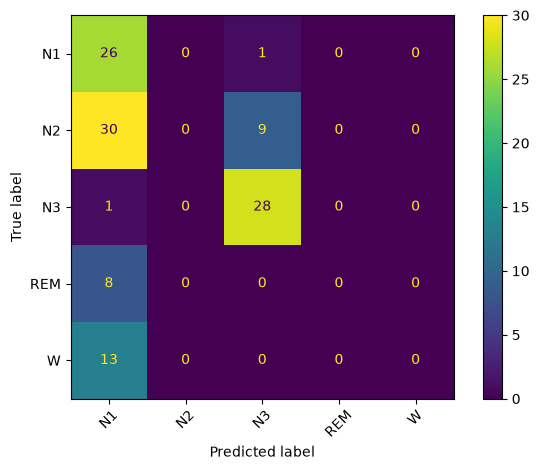

In [7]:
snn_model.eval()
with torch.no_grad():
    snn_counts, activity = snn_model(test_spikes)
    snn_prediction = snn_counts.argmax(dim=1).cpu().numpy()
snn_results = classification_metrics(y_test, snn_prediction)
print('SNN accuracy:', round(snn_results['accuracy'], 4))
print('SNN macro-F1:', round(snn_results['macro_f1'], 4))
print(snn_results['report'])
ConfusionMatrixDisplay(snn_results['confusion_matrix'],
                       display_labels=label_encoder.classes_).plot(xticks_rotation=45)
plt.tight_layout()

## 8. 脉冲动力学与活动量代理

`hidden_spikes` 和 `output_spikes` 记录测试样本在每个时间步的发放情况。栅格图中，横轴是 SNN 的计算时间步，纵轴是隐藏层神经元；深色位置表示该神经元在那个时间步发放了脉冲。

`spike_activity` 汇总总脉冲数、平均发放率（数组中为 1 的比例）和零脉冲比例。它们描述模型活动情况，**不是耗电量，也不是焦耳数**；没有硬件测量或可靠能耗模型时，不能仅凭脉冲更少就声称模型更省电。

隐藏层活动: {'spike_count': 21463.0, 'mean_firing_rate': 0.09034465998411179, 'zero_spike_fraction': 0.9096553407866379}
输出层活动: {'spike_count': 156.0, 'mean_firing_rate': 0.008405172266066074, 'zero_spike_fraction': 0.9915948275862069}


/var/folders/qh/9d4b65dx6mg5g2p8fyvw34pw0000gn/T/ipykernel_78459/3410847283.py:13: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/qh/9d4b65dx6mg5g2p8fyvw34pw0000gn/T/ipykernel_78459/3410847283.py:13: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/qh/9d4b65dx6mg5g2p8fyvw34pw0000gn/T/ipykernel_78459/3410847283.py:13: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/qh/9d4b65dx6mg5g2p8fyvw34pw0000gn/T/ipykernel_78459/3410847283.py:13: UserWarning: Glyph 38544 (\N{CJK UNIFIED IDEOGRAPH-9690}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/qh/9d4b65dx6mg5g2p8fyvw34pw0000gn/T/ipykernel_78459/3410847283.py:13: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/qh/9d4b

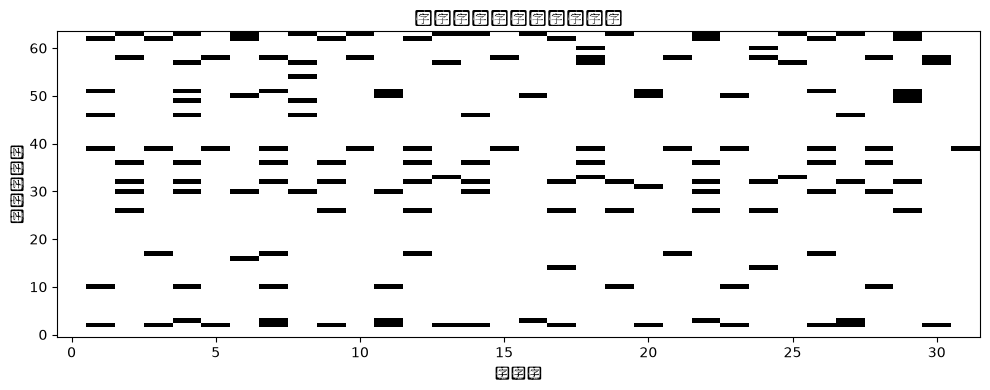

In [8]:
hidden_spikes = activity['hidden_spikes'].cpu().numpy()
output_spikes = activity['output_spikes'].cpu().numpy()
print('隐藏层活动:', spike_activity(hidden_spikes))
print('输出层活动:', spike_activity(output_spikes))

example_index = 0
plt.figure(figsize=(10, 4))
plt.imshow(hidden_spikes[:, example_index, :].T, aspect='auto',
           origin='lower', interpolation='nearest', cmap='Greys')
plt.xlabel('时间步')
plt.ylabel('隐藏神经元')
plt.title('测试样本隐藏层脉冲栅格')
plt.tight_layout()

# 脉冲数是活动量代理，不是焦耳或实测功耗。

## 9. 结果记录与解释

把 SVM、MLP、SNN 的 Accuracy 和 Macro-F1 放在一起比较，并结合混淆矩阵检查哪些阶段容易分错。分析时也要记下数据子集、训练/测试受试者、随机种子、时间步数、训练轮数和软件/硬件环境，以便之后重复实验。

这里仅有 2 位受试者，测试集也只有其中 1 位，因此指标会随受试者和随机脉冲变化，样本少的类别尤其不稳定。当前结果说明实验流程跑通，不足以证明模型能推广到一般人群；更可靠的结论需要更多受试者和重复评估。

脉冲数只能作为活动量代理；没有硬件测量或经过校准的能耗模型时，不得据此声称获得了真实能耗节省。

后续 OpenNeuro 听觉/嗅觉扩展需要先选定并核实数据集 ID、任务事件、标签和许可，再实现新的数据适配器。